In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import kagglehub
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [3]:
os.environ["KAGGLEHUB_CACHE"] = "data/kagglehub_cache"

path = kagglehub.dataset_download("aliiihussain/pubg-mobile-win-and-performance-prediction-dataset")

In [6]:
df = pd.read_csv("data/kagglehub_cache/datasets/aliiihussain/pubg-mobile-win-and-performance-prediction-dataset/versions/1/PUBG_Mobile_Win_Performance_Prediction_Dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

  Player_ID      Map       Tier  Kills  Damage_Dealt  Survival_Time_Minutes  \
0        P1   Sanhok   Platinum      4        441.86                  22.70   
1        P2    Livik  Conqueror      1        551.58                   5.58   
2        P3  Miramar  Conqueror      5        414.27                  14.64   
3        P4  Erangel        Ace      3        499.70                  18.00   
4        P5  Erangel   Platinum      7        751.11                  29.13   

   Headshot_Percentage  Assists  Revives  Distance_Travelled_km  \
0                 6.13        1        3                   7.54   
1                33.86        1        3                   7.80   
2                 5.88        1        3                   2.31   
3                35.07        5        4                   7.77   
4                38.39        4        0                   2.72   

   Longest_Kill_meters  Heals_Used  Boosts_Used  Match_Rank  Win  \
0                 5.27           4            0       

In [10]:
# Кодирование целевой переменной
le_target = LabelEncoder()
df['Tier_encoded'] = le_target.fit_transform(df['Tier'])
y = df['Tier_encoded']
X = df.drop(['Tier', 'Tier_encoded', 'Player_ID'], axis=1)

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер train до обработки: {X_train.shape}")
print(f"Размер test до обработки: {X_test.shape}")

# Разделение признаков на категориальные и численные
categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# Предобработка данных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nРазмер train после обработки: {X_train_processed.shape}")
print(f"Размер test после обработки: {X_test_processed.shape}")

print("\nКатегориальные:", categorical_cols)
print("Численные:", numeric_cols)

Размер train до обработки: (2000, 14)
Размер test до обработки: (500, 14)

Размер train после обработки: (2000, 23)
Размер test после обработки: (500, 23)

Категориальные: ['Map', 'Favorite_Weapon']
Численные: ['Kills', 'Damage_Dealt', 'Survival_Time_Minutes', 'Headshot_Percentage', 'Assists', 'Revives', 'Distance_Travelled_km', 'Longest_Kill_meters', 'Heals_Used', 'Boosts_Used', 'Match_Rank', 'Win']


In [12]:
print("Классы в исходном датасете")
print(df['Tier'].value_counts().sort_index())
print(f"Всего записей: {len(df)}")
print()

print("Классы в train")
unique, counts = np.unique(y_train, return_counts=True)
train_dist = dict(zip(unique, counts))
for code, count in sorted(train_dist.items()):
    label = le_target.inverse_transform([code])[0]
    print(f"{label} (код {code}): {count}")
print(f"Всего в train: {len(y_train)}")
print()

# Тестовая выборка  
print("Классы в test")
unique, counts = np.unique(y_test, return_counts=True)
test_dist = dict(zip(unique, counts))
for code, count in sorted(test_dist.items()):
    label = le_target.inverse_transform([code])[0]
    print(f"{label} (код {code}): {count}")
print(f"Всего в test: {len(y_test)}")
print()

Классы в исходном датасете
Tier
Ace          331
Bronze       309
Conqueror    309
Crown        335
Diamond      302
Gold         301
Platinum     299
Silver       314
Name: count, dtype: int64
Всего записей: 2500

Классы в train
Ace (код 0): 265
Bronze (код 1): 247
Conqueror (код 2): 247
Crown (код 3): 268
Diamond (код 4): 242
Gold (код 5): 241
Platinum (код 6): 239
Silver (код 7): 251
Всего в train: 2000

Классы в test
Ace (код 0): 66
Bronze (код 1): 62
Conqueror (код 2): 62
Crown (код 3): 67
Diamond (код 4): 60
Gold (код 5): 60
Platinum (код 6): 60
Silver (код 7): 63
Всего в test: 500



KL-дивергенция на train: 2.5242


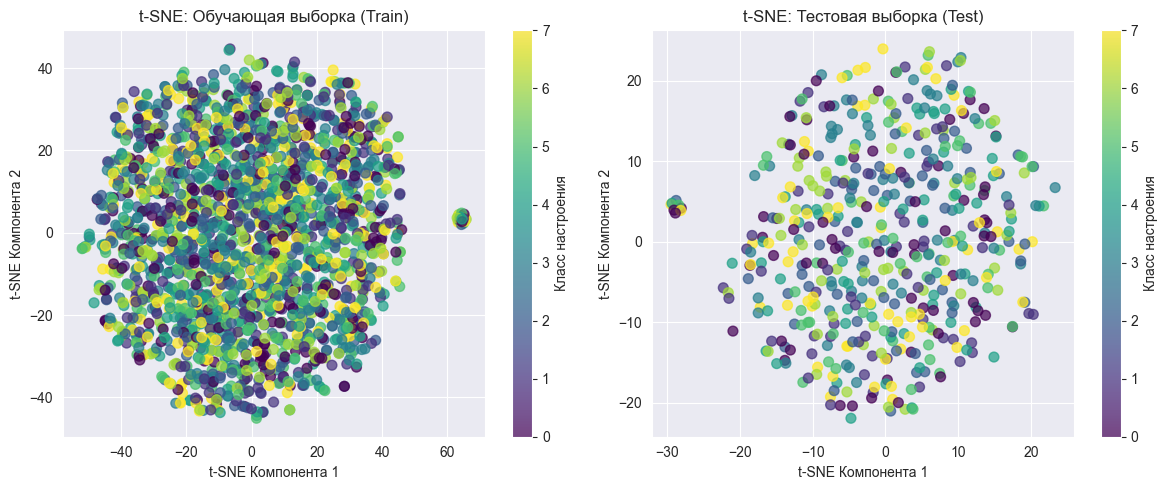

Метки классов настроения: {'Ace': np.int64(0), 'Bronze': np.int64(1), 'Conqueror': np.int64(2), 'Crown': np.int64(3), 'Diamond': np.int64(4), 'Gold': np.int64(5), 'Platinum': np.int64(6), 'Silver': np.int64(7)}


In [15]:
tsne = TSNE(n_components=2, perplexity=min(30, len(X_train_processed)-1),
            random_state=42, learning_rate='auto')
X_tsne_train = tsne.fit_transform(X_train_processed)

print(f"KL-дивергенция на train: {tsne.kl_divergence_:.4f}")

plt.figure(figsize=(12, 5))

# train
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_tsne_train[:, 0], X_tsne_train[:, 1],
                      c=y_train, cmap='viridis', alpha=0.7, s=50)
plt.xlabel('t-SNE Компонента 1')
plt.ylabel('t-SNE Компонента 2')
plt.title('t-SNE: Обучающая выборка (Train)')
plt.colorbar(scatter, label='Класс настроения')

X_tsne_test = tsne.fit_transform(X_test_processed)

# test
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_tsne_test[:, 0], X_tsne_test[:, 1],
                      c=y_test, cmap='viridis', alpha=0.7, s=50)
plt.xlabel('t-SNE Компонента 1')
plt.ylabel('t-SNE Компонента 2')
plt.title('t-SNE: Тестовая выборка (Test)')
plt.colorbar(scatter, label='Класс настроения')

plt.tight_layout()
plt.show()

# Печать меток классов для интерпретации
print("Метки классов настроения:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Accuracy на train: 0.699
Accuracy на test:  0.116

Метрики по классам
              precision    recall  f1-score   support

         Ace       0.10      0.08      0.09        66
      Bronze       0.12      0.11      0.12        62
   Conqueror       0.08      0.11      0.09        62
       Crown       0.14      0.19      0.16        67
     Diamond       0.13      0.08      0.10        60
        Gold       0.10      0.08      0.09        60
    Platinum       0.12      0.13      0.12        60
      Silver       0.17      0.13      0.15        63

    accuracy                           0.12       500
   macro avg       0.12      0.12      0.11       500
weighted avg       0.12      0.12      0.11       500



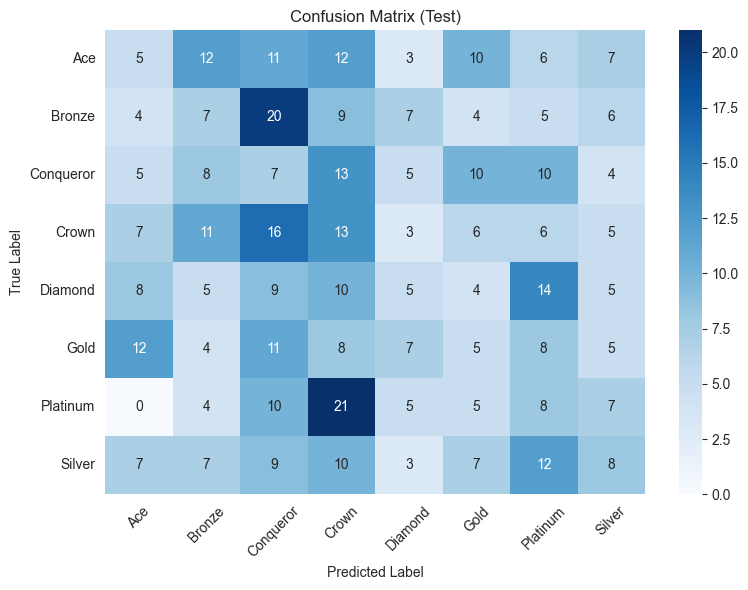


Самые важные признаки
Survival_Time_Minutes          0.119
Longest_Kill_meters            0.111
Damage_Dealt                   0.109
Headshot_Percentage            0.104
Distance_Travelled_km          0.096
Match_Rank                     0.093
Heals_Used                     0.063
Boosts_Used                    0.058
Kills                          0.055
Assists                        0.042


In [17]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=6,
                            min_samples_split=10,
                            min_samples_leaf=5,
                            class_weight='balanced',
                            random_state=42)
rf.fit(X_train_processed, y_train)

y_pred_train = rf.predict(X_train_processed)
y_pred_test = rf.predict(X_test_processed)

print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test):.3f}")
print()

print("Метрики по классам")
target_names = le_target.classes_
print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# самые важные признаки
feature_names = (numeric_cols +
                 list(preprocessor.named_transformers_['cat']
                      .get_feature_names_out(categorical_cols)))
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-10:]

print("\nСамые важные признаки")
for i in top_idx[::-1]:
    print(f"{feature_names[i]:30} {importances[i]:.3f}")

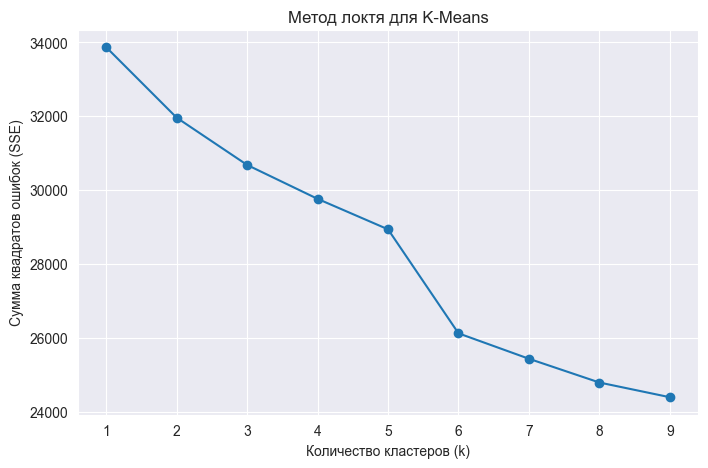

In [19]:
# Диапазон числа кластеров для проверки
cluster_range = range(1, 10)

X_scaled = np.vstack([X_train_processed, X_test_processed])

sse = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)  # inertia_ — это сумма квадратов расстояний до центров

# Строим график "локтя"
plt.figure(figsize=(8,5))
plt.plot(cluster_range, sse, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов ошибок (SSE)')
plt.title('Метод локтя для K-Means')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [20]:
k_opt = 8

# K-Means
kmeans_opt = KMeans(n_clusters=k_opt, random_state=42).fit(X_scaled)

df['kmeans_opt'] = kmeans_opt.labels_

In [21]:
def evaluate_clusters(X, labels, name):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"{name}: Silhouette={sil:.3f}, Davies-Bouldin={db:.3f}")

evaluate_clusters(X_scaled, df['kmeans_opt'], f"K-Means {k_opt} кластеров")

K-Means 8 кластеров: Silhouette=0.060, Davies-Bouldin=2.446
